# Assignment 4: Decision Tree Model and Business Interpretation
**Course:** MBAI 5310G-001 — AI Programming  
**Institution:** Ontario Tech University  
**Lecturer:** Zahra Atf  
**Dataset:** Evergreen Bank Credit Card Upgrade Dataset

---

## Task 1: Understand the Business Problem

**What is the business about?**

Evergreen Bank is a mid-sized retail banking institution that provides everyday
banking, savings products, loans, and credit cards to individual and small
business customers.

The bank is focused on growing its credit card revenue by encouraging existing
customers to upgrade from lower-tier cards to premium reward cards.

Premium cards generate higher annual fees, interchange revenue, and stronger
customer loyalty when offered to the right customers.

**What problem is the business trying to solve?**

The bank currently uses simple rule-based targeting to send upgrade offers,
such as contacting all customers with high monthly spending. This approach
misses complex patterns — for example, a customer with moderate spending but
high travel activity and strong digital engagement may be more likely to accept
than a high-spender with low satisfaction and recent late payments.

The bank needs a smarter way to identify which customers are genuinely likely
to accept an upgrade offer, while avoiding unnecessary outreach to customers
who are not interested.


**What decision can machine learning help the business make?**

Machine learning can help the bank predict whether a specific customer is
likely to accept a credit card upgrade offer.

This allows the bank to prioritize outreach to the most promising customers,
rather than sending offers to everyone.

The result is a more efficient campaign that reduces wasted marketing spend
and improves the customer experience.

**What is the target variable in the dataset?**

The target variable is **Accepted_Card_Upgrade**.

It is a binary column with two possible values:
- **Yes** — the customer accepted the upgrade offer
- **No** — the customer did not accept the upgrade offer

**What are the input features?**

The input features are grouped into five categories:

- **Customer profile:** Age_Group, Income_Band, Employment_Status, Region, Customer_Segment
- **Banking relationship:** Customer_Tenure_Months, Current_Card_Tier
- **Card usage:** Avg_Monthly_Card_Spend, Travel_Spend_Share_Pct, Dining_Spend_Share_Pct, Reward_Points_Balance
- **Engagement:** Preferred_Channel, Digital_App_Logins_30D, Prior_Offer_Emails_Opened_6M, Branch_Advisor_Contact
- **Risk and experience:** Credit_Score_Band, Credit_Utilization_Pct, Late_Payments_12M, Customer_Satisfaction_Score

Note: Customer_ID is excluded because it is only an identifier and has
no predictive value.

In [1]:
# Import pandas to work with data tables
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib to create charts and graphs
import matplotlib.pyplot as plt

# Import display to show tables nicely in the notebook
from IPython.display import display

# Store the file path in a variable
file_path = "/Users/mr_quayci/Downloads/evergreen_bank_credit_card_upgrade_business_plan/evergreen_bank_credit_card_upgrade_dataset.xlsx"

# Read the Excel file and load it into a pandas DataFrame
df = pd.read_excel(file_path)

# Confirm the dataset loaded successfully
print("Dataset loaded successfully!")

# Print the number of rows and columns
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())

Dataset loaded successfully!
Dataset shape: (340, 21)


,Customer_ID,Age_Group,Income_Band,Credit_Score_Band,Current_Card_Tier,Customer_Segment,Preferred_Channel,Region,Employment_Status,Customer_Tenure_Months,...,Travel_Spend_Share_Pct,Dining_Spend_Share_Pct,Digital_App_Logins_30D,Reward_Points_Balance,Prior_Offer_Emails_Opened_6M,Credit_Utilization_Pct,Late_Payments_12M,Customer_Satisfaction_Score,Branch_Advisor_Contact,Accepted_Card_Upgrade
0,EB10001,46-55,150K_Plus,Excellent,Silver,Family,Branch,Urban,Employed,48,...,3.3,14.9,1,12039,2,23.8,0,8,No,Yes
1,EB10002,56-65,40K_70K,Fair,Basic,Family,Email,Suburban,Employed,90,...,24.4,26.4,3,6632,4,68.2,0,6,No,No
2,EB10003,26-35,70K_100K,Very_Good,Classic,Family,Mobile_App,Small_Town,Employed,3,...,15.2,22.4,16,5492,2,27.9,0,10,No,Yes
3,EB10004,26-35,150K_Plus,Good,Basic,Young_Professional,Mobile_App,Urban,Employed,18,...,43.0,21.1,19,8067,5,40.4,1,8,No,Yes
4,EB10005,36-45,70K_100K,Excellent,Silver,Established_Professional,Email,Urban,Employed,80,...,6.0,28.5,0,10602,3,22.3,0,6,No,Yes


In [2]:
# Display the last five rows of the dataset
print("Last Five Rows")
print("-" * 50)
display(df.tail())

Last Five Rows
--------------------------------------------------


,Customer_ID,Age_Group,Income_Band,Credit_Score_Band,Current_Card_Tier,Customer_Segment,Preferred_Channel,Region,Employment_Status,Customer_Tenure_Months,...,Travel_Spend_Share_Pct,Dining_Spend_Share_Pct,Digital_App_Logins_30D,Reward_Points_Balance,Prior_Offer_Emails_Opened_6M,Credit_Utilization_Pct,Late_Payments_12M,Customer_Satisfaction_Score,Branch_Advisor_Contact,Accepted_Card_Upgrade
335,EB10336,36-45,150K_Plus,Very_Good,Classic,Young_Professional,SMS,Suburban,Employed,47,...,28.7,16.5,6,9789,5,26.9,0,7,Yes,Yes
336,EB10337,46-55,40K_70K,Good,Classic,Small_Business_Owner,Mobile_App,Suburban,Employed,70,...,0.0,19.5,26,2976,2,45.4,0,5,No,No
337,EB10338,36-45,40K_70K,Excellent,Basic,Student,Mobile_App,Urban,Self_Employed,23,...,0.0,26.8,22,2591,2,5.0,0,8,No,Yes
338,EB10339,18-25,100K_150K,Fair,Silver,Young_Professional,Email,Urban,Employed,9,...,23.5,18.1,8,12886,7,52.8,1,6,No,No
339,EB10340,46-55,40K_70K,Good,Classic,Small_Business_Owner,Email,Urban,Employed,52,...,2.0,10.7,0,5047,6,63.1,1,8,No,No


In [3]:
# Check the number of rows and columns
print("Dataset Shape")
print("-" * 50)
print(df.shape)

Dataset Shape
--------------------------------------------------
(340, 21)


In [4]:
# Count missing values in each column
print("Missing Values")
print("-" * 50)
display(df.isnull().sum())

Missing Values
--------------------------------------------------


Customer_ID                     0
Age_Group                       0
Income_Band                     0
Credit_Score_Band               0
Current_Card_Tier               0
Customer_Segment                0
Preferred_Channel               0
Region                          0
Employment_Status               0
Customer_Tenure_Months          0
Avg_Monthly_Card_Spend          0
Travel_Spend_Share_Pct          0
Dining_Spend_Share_Pct          0
Digital_App_Logins_30D          0
Reward_Points_Balance           0
Prior_Offer_Emails_Opened_6M    0
Credit_Utilization_Pct          0
Late_Payments_12M               0
Customer_Satisfaction_Score     0
Branch_Advisor_Contact          0
Accepted_Card_Upgrade           0
dtype: int64

In [6]:
# Count duplicate rows
print("Duplicate Rows")
print("-" * 50)
print(df.duplicated().sum())

Duplicate Rows
--------------------------------------------------
0


In [7]:
# Show summary statistics for numerical columns
print("Summary Statistics")
print("-" * 50)
display(df.describe())# 

Summary Statistics
--------------------------------------------------


,Customer_Tenure_Months,Avg_Monthly_Card_Spend,Travel_Spend_Share_Pct,Dining_Spend_Share_Pct,Digital_App_Logins_30D,Reward_Points_Balance,Prior_Offer_Emails_Opened_6M,Credit_Utilization_Pct,Late_Payments_12M,Customer_Satisfaction_Score
count,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000
mean,45.794118,983.802941,18.288235,20.336176,10.023529,5980.697059,3.097059,45.564706,0.576471,7.073529
std,27.187733,465.049183,10.168276,8.245643,7.422324,2797.254765,2.228666,19.079470,0.936024,1.462573
min,2.000000,80.000000,0.000000,2.000000,0.000000,344.000000,0.000000,5.000000,0.000000,3.000000
25%,24.000000,651.250000,11.025000,14.075000,4.000000,4047.500000,1.000000,32.500000,0.000000,6.000000
50%,44.500000,916.000000,19.000000,20.600000,9.000000,5605.000000,3.000000,44.400000,0.000000,7.000000
75%,67.250000,1277.500000,25.525000,26.000000,16.000000,7655.250000,5.000000,58.100000,1.000000,8.000000
max,129.000000,2787.000000,45.000000,48.300000,30.000000,17451.000000,10.000000,95.000000,4.000000,10.000000


In [8]:
# Store the target column name in a variable
target_column = "Accepted_Card_Upgrade"

# Print the target variable name
print("Target variable:", target_column)

# Display the unique values in the target column
print("Target variable values:", df[target_column].unique())

# Count how many customers are in each target class
print("\nTarget class distribution:")
display(df[target_column].value_counts())

Target variable: Accepted_Card_Upgrade
Target variable values: ['Yes' 'No']

Target class distribution:


Accepted_Card_Upgrade
No     211
Yes    129
Name: count, dtype: int64

In [9]:
# Create a copy of the original dataset to avoid modifying it
df_clean = df.copy()

# Remove Customer_ID — it is only an identifier and has no predictive value
df_clean = df_clean.drop(columns=["Customer_ID"])
print("Customer_ID removed.")

# Count duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Count duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()
print(f"Duplicate rows removed: {duplicates_before} before, {duplicates_after} after")

# Confirm the shape after cleaning
print("Dataset shape after cleaning:", df_clean.shape)

Customer_ID removed.
Duplicate rows removed: 0 before, 0 after
Dataset shape after cleaning: (340, 20)


In [10]:
# Identify numerical and categorical columns
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = [c for c in df_clean.select_dtypes(include=["object"]).columns if c != target_column]

print("Numerical columns:", numerical_columns)
print("-" * 50)
print("Categorical columns:", categorical_columns)

# Fill missing values in numerical columns with the median
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing values in categorical columns with the most frequent value
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Confirm no missing values remain
print("\nMissing Values After Handling")
print("-" * 50)
display(df_clean.isnull().sum())

Numerical columns: ['Customer_Tenure_Months', 'Avg_Monthly_Card_Spend', 'Travel_Spend_Share_Pct', 'Dining_Spend_Share_Pct', 'Digital_App_Logins_30D', 'Reward_Points_Balance', 'Prior_Offer_Emails_Opened_6M', 'Credit_Utilization_Pct', 'Late_Payments_12M', 'Customer_Satisfaction_Score']
--------------------------------------------------
Categorical columns: ['Age_Group', 'Income_Band', 'Credit_Score_Band', 'Current_Card_Tier', 'Customer_Segment', 'Preferred_Channel', 'Region', 'Employment_Status', 'Branch_Advisor_Contact']

Missing Values After Handling
--------------------------------------------------


Age_Group                       0
Income_Band                     0
Credit_Score_Band               0
Current_Card_Tier               0
Customer_Segment                0
Preferred_Channel               0
Region                          0
Employment_Status               0
Customer_Tenure_Months          0
Avg_Monthly_Card_Spend          0
Travel_Spend_Share_Pct          0
Dining_Spend_Share_Pct          0
Digital_App_Logins_30D          0
Reward_Points_Balance           0
Prior_Offer_Emails_Opened_6M    0
Credit_Utilization_Pct          0
Late_Payments_12M               0
Customer_Satisfaction_Score     0
Branch_Advisor_Contact          0
Accepted_Card_Upgrade           0
dtype: int64

In [11]:
# Separate features (X) and target variable (y)
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

print("Feature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)

# Show target distribution
print("\nTarget distribution:")
display(y.value_counts())

Feature matrix shape (X): (340, 19)
Target vector shape (y): (340,)

Target distribution:


Accepted_Card_Upgrade
No     211
Yes    129
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=False)
print("Encoded feature matrix shape:", X_encoded.shape)

# Encode target variable: No = 0, Yes = 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Target classes:", le.classes_)

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set size:", X_train.shape[0])
print("Testing set size: ", X_test.shape[0])

Encoded feature matrix shape: (340, 51)
Target classes: ['No' 'Yes']
Training set size: 272
Testing set size:  68


## Task 3: Train a Decision Tree Classification Model

### Introduction to Decision Trees

A Decision Tree is a machine learning model that makes predictions by learning
simple decision rules from the data. The rules are organized like a tree, where
each node asks a question about a feature, and each branch represents the answer.
The model keeps splitting the data until it reaches a final prediction at the
leaf nodes.

Decision Trees are useful because they are easy to understand and can show which
features are most important in making a prediction. In business analytics, they
can help answer questions such as:
- Which customers are likely to accept a product offer?
- Which factors most influence customer behavior?
- Which features are most important for predicting a business outcome?

### How Decision Trees Make Predictions

A Decision Tree makes predictions by asking a series of yes/no questions about
the input features. Starting from the root node at the top, the tree splits the
data based on the feature that best separates the classes.

For example, in this business problem the tree might ask:
- Is the Credit_Utilization_Pct less than 44.5?
- Is the Travel_Spend_Share_Pct greater than 19.8?
- Is the Credit_Score_Band Excellent?

At each step, the model follows the branch that matches the customer's data
until it reaches a leaf node, which gives the final prediction — either
**Yes** (will accept the upgrade) or **No** (will not accept).

The deeper the tree, the more specific the rules become. However, a tree
that is too deep may memorize the training data instead of learning
generalizable patterns — this is called overfitting.

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Decision Tree model trained successfully!
Tree depth: 10
Number of leaves: 48


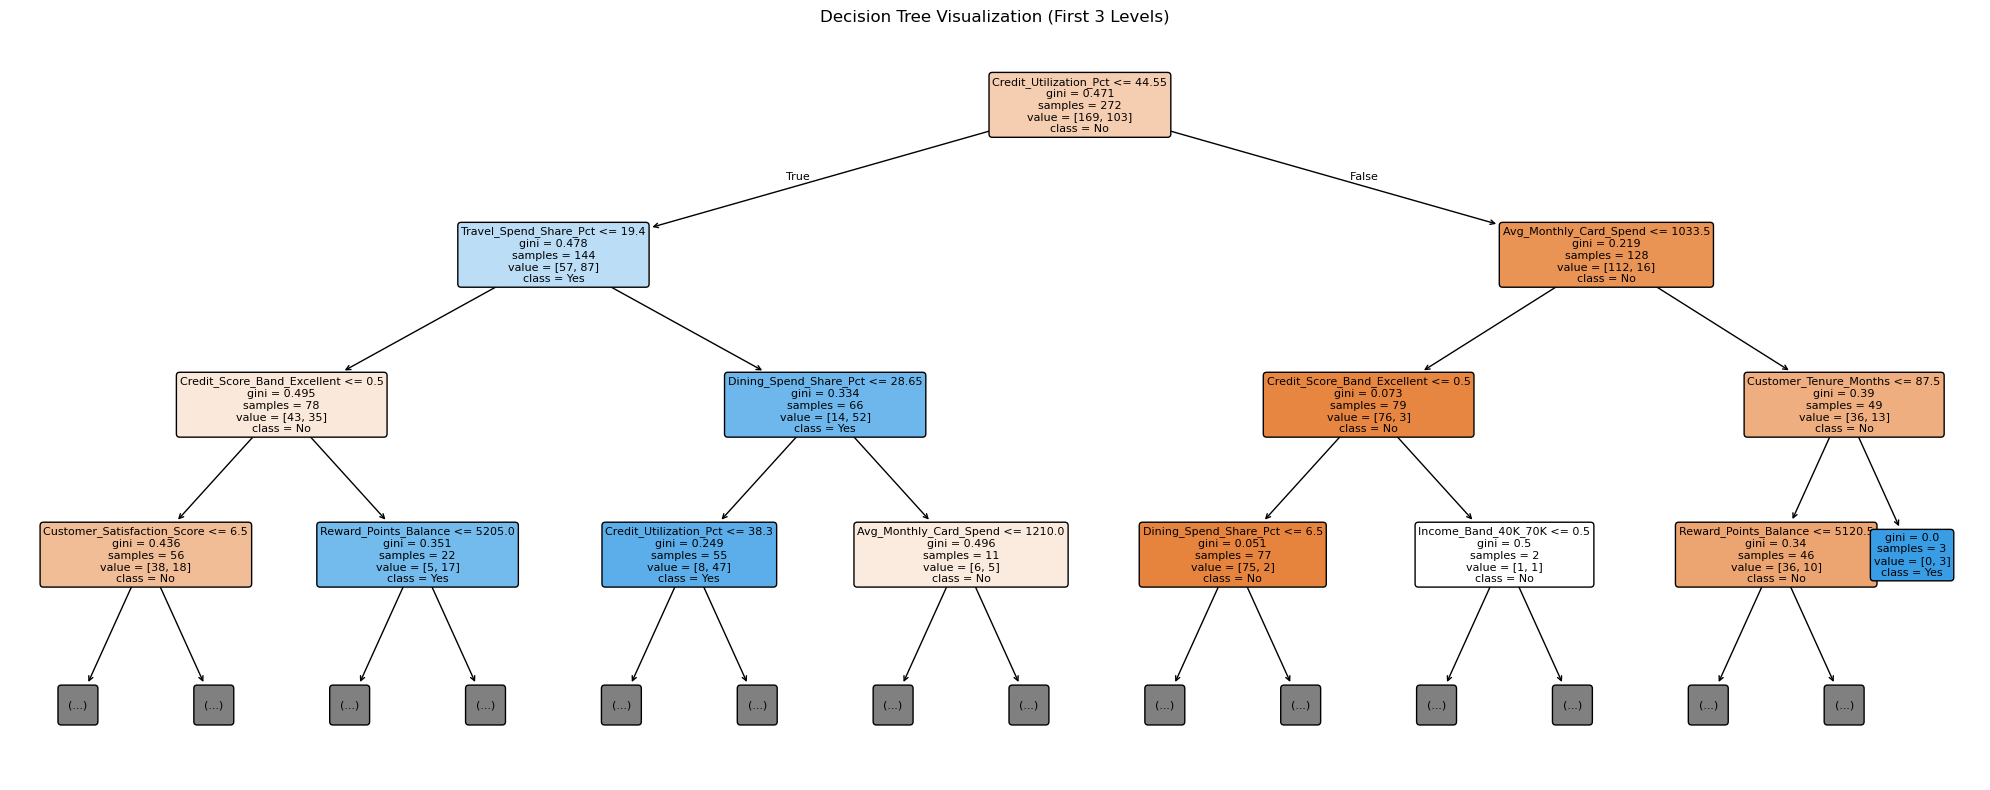

In [14]:
from sklearn.tree import plot_tree

# Visualize the Decision Tree (limited to depth 3 for readability)
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X_encoded.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization (First 3 Levels)")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score

# Predict on training and testing sets
y_train_pred = dt_model.predict(X_train)
y_test_pred  = dt_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)

print("Training Accuracy: {:.4f} ({:.1f}%)".format(train_accuracy, train_accuracy * 100))
print("Testing Accuracy:  {:.4f} ({:.1f}%)".format(test_accuracy,  test_accuracy  * 100))
print("Gap:               {:.1f} percentage points".format((train_accuracy - test_accuracy) * 100))

Training Accuracy: 1.0000 (100.0%)
Testing Accuracy:  0.6324 (63.2%)
Gap:               36.8 percentage points


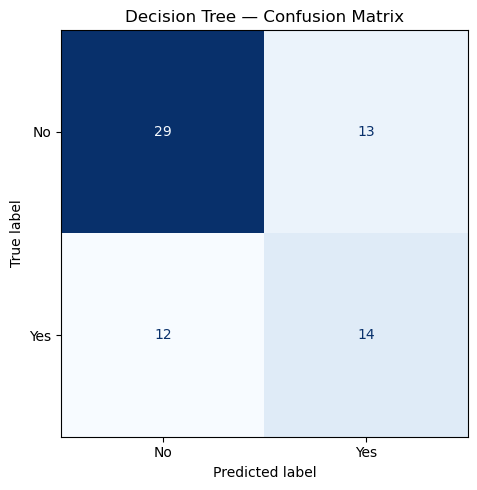

True Negatives  (TN): 29
False Positives (FP): 13
False Negatives (FN): 12
True Positives  (TP): 14


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

In [17]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("Classification Report")
print("-" * 50)
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

precision = precision_score(y_test, y_test_pred)
recall    = recall_score(y_test, y_test_pred)
f1        = f1_score(y_test, y_test_pred)

print("Summary (Yes class):")
print(f"  Accuracy  : {test_accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.71      0.69      0.70        42
         Yes       0.52      0.54      0.53        26

    accuracy                           0.63        68
   macro avg       0.61      0.61      0.61        68
weighted avg       0.64      0.63      0.63        68

Summary (Yes class):
  Accuracy  : 0.6324
  Precision : 0.5185
  Recall    : 0.5385
  F1-Score  : 0.5283


In [18]:
# Overfitting check
print("Overfitting Analysis")
print("-" * 50)
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Difference        : {train_accuracy - test_accuracy:.4f}")
print()
print("The model is OVERFITTING.")
print(f"Training accuracy is {train_accuracy*100:.1f}% but testing accuracy is only {test_accuracy*100:.1f}%.")
print(f"A gap of {(train_accuracy - test_accuracy)*100:.1f} percentage points means the tree memorized the")
print("training data and does not generalize well to new customers.")
print("Applying max_depth or min_samples_leaf would reduce overfitting.")

Overfitting Analysis
--------------------------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 0.6324
Difference        : 0.3676

The model is OVERFITTING.
Training accuracy is 100.0% but testing accuracy is only 63.2%.
A gap of 36.8 percentage points means the tree memorized the
training data and does not generalize well to new customers.
Applying max_depth or min_samples_leaf would reduce overfitting.


### Controlling Decision Tree Complexity

One way to reduce overfitting is to limit the depth of the tree using the
`max_depth` parameter. This stops the tree from growing too deep and memorizing
the training data. A shallower tree learns more general rules that work better
on new, unseen customers.

In [19]:
# Train a simpler Decision Tree with max_depth = 4
dt_simple = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_simple.fit(X_train, y_train)

# Evaluate the simpler model
simple_train_acc = accuracy_score(y_train, dt_simple.predict(X_train))
simple_test_acc  = accuracy_score(y_test,  dt_simple.predict(X_test))

print("Simpler Decision Tree (max_depth=4)")
print("-" * 50)
print(f"Training Accuracy : {simple_train_acc:.4f} ({simple_train_acc*100:.1f}%)")
print(f"Testing Accuracy  : {simple_test_acc:.4f}  ({simple_test_acc*100:.1f}%)")
print(f"Gap               : {(simple_train_acc - simple_test_acc)*100:.1f} percentage points")

Simpler Decision Tree (max_depth=4)
--------------------------------------------------
Training Accuracy : 0.8456 (84.6%)
Testing Accuracy  : 0.6912  (69.1%)
Gap               : 15.4 percentage points


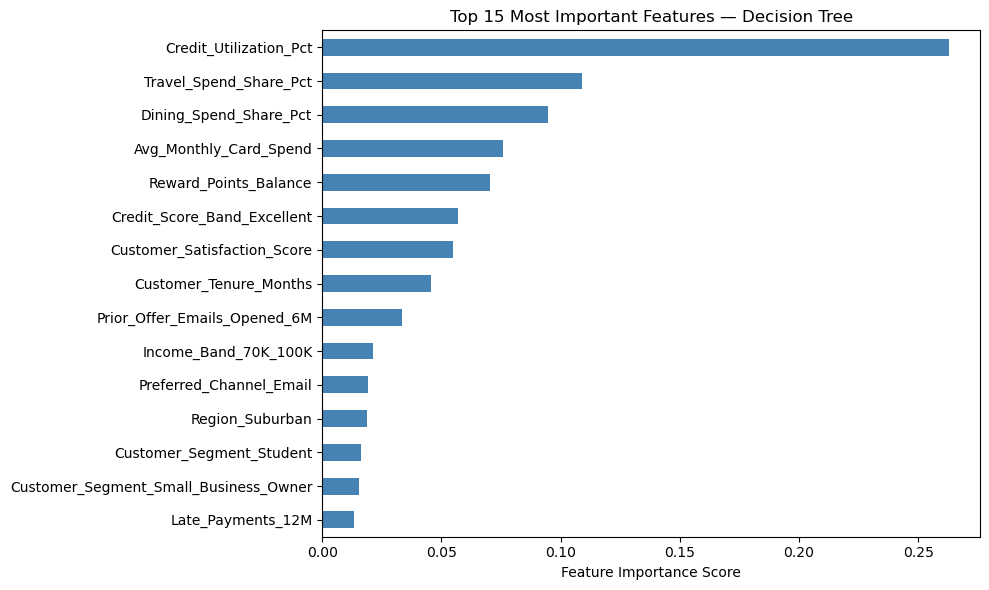


Top 15 Feature Importances:


,Feature,Importance
0,Credit_Utilization_Pct,0.262792
1,Travel_Spend_Share_Pct,0.108783
2,Dining_Spend_Share_Pct,0.094679
3,Avg_Monthly_Card_Spend,0.075793
4,Reward_Points_Balance,0.070544
5,Credit_Score_Band_Excellent,0.057112
6,Customer_Satisfaction_Score,0.054969
7,Customer_Tenure_Months,0.045556
8,Prior_Offer_Emails_Opened_6M,0.033484
9,Income_Band_70K_100K,0.021486


In [21]:
# Extract and visualize top feature importances
importances = pd.Series(dt_model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features — Decision Tree")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 15 Feature Importances:")
display(importances.reset_index().rename(columns={"index": "Feature", 0: "Importance"}))

## Task 4: Business Interpretation of Model Results

**How well did the Decision Tree model perform?**

The model achieved a testing accuracy of 63.2% (43 out of 68 test records
correctly classified). The precision for the "Yes" class is 51.9%, recall
is 53.8%, and F1-score is 52.8%. This means the model correctly identifies
roughly half of the true acceptors, and about half its positive predictions
are correct. The performance provides some lift over random targeting but
leaves significant room for improvement. When the tree was constrained to
max_depth=4, testing accuracy improved to 69.1% with a much smaller gap,
showing that a simpler tree generalizes better.

**Is there a large difference between training accuracy and testing accuracy?**

Yes — the gap is very large. The unconstrained model achieved 100% training
accuracy but only 63.2% testing accuracy, a difference of 36.8 percentage
points. This means the tree memorized every training record perfectly but
fails to generalize to new customers it has not seen before.

**Does the model show signs of overfitting? Why or why not?**

Yes, strongly. Without constraints, the Decision Tree grew 10 levels deep
with 48 leaves, fitting every nuance of the 272 training records. When
max_depth was limited to 4, the gap dropped to 15.4 percentage points and
testing accuracy improved — confirming that the original tree was overfitting.
In a real business setting, hyperparameter tuning would be applied before
using the model for any customer targeting.

**Which evaluation metric is most important for this business problem?**

Precision is the most important metric for Evergreen Bank's upgrade campaign.
High precision means most customers flagged as likely acceptors actually do
accept, which protects the marketing budget and customer experience. With a
current precision of 51.9% for the "Yes" class, about half the outreach goes
to uninterested customers. Recall is also important if the bank cannot afford
to miss receptive customers, and the F1-score balances both concerns.

**What do false positives mean in this business context?**

A false positive means the model predicted a customer would accept the upgrade,
but they did not. There were 13 false positives in the test set. For Evergreen
Bank, this means 13 customers received outreach — emails, app notifications,
or advisor calls — that were irrelevant to them. This wastes marketing budget
and risks annoying customers with unwanted contact, reducing trust and
satisfaction.

**What do false negatives mean in this business context?**

A false negative means the model predicted a customer would not accept, but
they actually would have. There were 12 false negatives in the test set. For
Evergreen Bank, this means 12 customers who were ready to upgrade never
received an offer. The bank missed potential annual fee revenue, interchange
revenue, and the opportunity to deepen those customer relationships.

**Which features were most important in the Decision Tree model?**

The top features were:
1. Credit_Utilization_Pct (26.3%) — the strongest predictor
2. Travel_Spend_Share_Pct (10.9%) — travel activity signals premium card suitability
3. Dining_Spend_Share_Pct (9.5%) — lifestyle spending patterns
4. Avg_Monthly_Card_Spend (7.6%) — overall card activity
5. Reward_Points_Balance (7.1%) — engagement with existing rewards
6. Credit_Score_Band_Excellent (5.7%) — creditworthiness for premium products
7. Customer_Satisfaction_Score (5.5%) — satisfied customers are more receptive
8. Customer_Tenure_Months (4.6%) — long-standing customers trust the bank more

**How can these important features help the business make better decisions?**

Credit utilization can be used as a first-pass screening criterion — customers
with moderate utilization are actively using their card without being
overextended, making them prime upgrade candidates. Travel and dining spend
shares identify lifestyle fit, as customers spending heavily in these categories
will immediately benefit from a premium rewards card. Reward points balance
signals program engagement — customers who actively accumulate points may be
ready for a higher tier. High satisfaction and long tenure identify the bank's
most loyal customers — the best candidates for deepening the relationship
through a premium product offer.

**What is one possible limitation or bias in the model or dataset?**

The dataset is synthetic and contains only 340 records, which is too small
for a reliable production model and contributes to overfitting. Features like
Income

## Limitations of Tree-Based Models

While Decision Trees are useful and easy to interpret, they have several
important limitations that should be considered before using them in a
real business setting:

- **Overfitting:** Without constraints, Decision Trees can grow too deep
  and memorize the training data, leading to poor performance on new data.

- **Instability:** Small changes in the training data can result in a
  completely different tree structure, making the model unstable.

- **Imbalanced classes:** When one class has significantly more records
  than the other, the tree may be biased toward predicting the majority
  class more often.

- **Limited generalization:** A Decision Tree trained on a small or
  synthetic dataset like this one may not capture the full complexity
  of real customer behavior.

- **No probability calibration:** The model predicts a class label but
  does not always produce well-calibrated probability estimates, which
  limits its use in risk-scored targeting.

## Responsible AI Reflection

Machine learning models used in financial services can affect real customers
and must be developed and applied responsibly.

- **Fairness:** Features like Income_Band, Age_Group, and Region may cause
  the model to systematically disadvantage certain customer groups. The bank
  must check whether upgrade offers are being recommended fairly across all
  demographics.

- **Transparency:** The Decision Tree is interpretable, which is an advantage
  in banking — managers and auditors can follow the decision rules. However,
  the model should still be reviewed by qualified staff before use.

- **Human oversight:** Model outputs should support human decision-making,
  not replace it. Credit suitability, affordability, and customer consent
  cannot be fully captured by a machine learning model.

- **Data quality:** This dataset is synthetic and simplified. A real
  deployment would require higher-quality data, regulatory approval, and
  ongoing monitoring for bias and model drift.

## Final Conclusion

This notebook built and evaluated a Decision Tree classification model to
predict whether Evergreen Bank customers are likely to accept a credit card
upgrade offer.

The model achieved a testing accuracy of 63.2%, with precision of 51.9%,
recall of 53.8%, and F1-score of 52.8% for the "Yes" class. The unconstrained
tree showed severe overfitting — 100% training accuracy versus 63.2% testing
accuracy. When tree depth was limited to 4, testing accuracy improved to 69.1%
with a much smaller gap, demonstrating the importance of controlling model
complexity.

The most important predictors were Credit_Utilization_Pct, Travel_Spend_Share_Pct,
Dining_Spend_Share_Pct, Avg_Monthly_Card_Spend, and Reward_Points_Balance.
These features reflect spending behavior, lifestyle fit, and program engagement
— all of which are strong signals of upgrade acceptance.

From a business perspective, the model provides a useful starting point for
customer targeting but should not be used in isolation. Human review, product
eligibility checks, affordability assessments, and fairness evaluations are
all necessary before launching any upgrade campaign based on model results.

A more robust deployment would benefit from a larger real-world dataset,
hyperparameter tuning, and a more powerful algorithm such as Random Forest
or Gradient Boosting.